# Proyek Analisis Data: PRSA Air Quality Dataset
- **Nama:** Karen Yemima Suy
- **Email:** cdcc006d6x2526@student.devacademy.id
- **ID Dicoding:** CDCC006D6X2526

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

- **Pertanyaan 1:** Bagaimana tren rata-rata PM2.5 pada seluruh stasiun kualitas udara selama periode 2013-2017?
- **Pertanyaan 2:** Pada bulan apa rata-rata PM2.5 tertinggi terjadi selama periode 2013-2017?
- **Pertanyaan 3:** Arah angin mana yang memiliki rata-rata PM2.5 tertinggi selama periode 2013-2017?

## Import Semua Packages/Library yang Digunakan

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
df1 = pd.read_csv("/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv", delimiter=",")
df2 = pd.read_csv("/content/PRSA_Data_Changping_20130301-20170228.csv", delimiter=",")
df3 = pd.read_csv("/content/PRSA_Data_Dingling_20130301-20170228.csv", delimiter=",")
df4 = pd.read_csv("/content/PRSA_Data_Dongsi_20130301-20170228.csv", delimiter=",")
df5 = pd.read_csv("/content/PRSA_Data_Guanyuan_20130301-20170228.csv", delimiter=",")
df6 = pd.read_csv("/content/PRSA_Data_Gucheng_20130301-20170228.csv", delimiter=",")
df7 = pd.read_csv("/content/PRSA_Data_Huairou_20130301-20170228.csv", delimiter=",")
df8 = pd.read_csv("/content/PRSA_Data_Nongzhanguan_20130301-20170228.csv", delimiter=",")
df9 = pd.read_csv("/content/PRSA_Data_Shunyi_20130301-20170228.csv", delimiter=",")
df10 = pd.read_csv("/content/PRSA_Data_Tiantan_20130301-20170228.csv", delimiter=",")
df11 = pd.read_csv("/content/PRSA_Data_Wanliu_20130301-20170228.csv", delimiter=",")
df12 = pd.read_csv("/content/PRSA_Data_Wanshouxigong_20130301-20170228.csv", delimiter=",")

all_df = pd.concat([
    df1, df2, df3, df4, df5, df6,
    df7, df8, df9, df10, df11, df12
], ignore_index=True)

all_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Dataset berhasil digabungkan menjadi satu dataframe bernama all_df
- Dataset berisi data kualitas udara dari 12 stasiun pengamatan selama periode 2013-2017.

### Assessing Data

#### Identifying Quality problem

In [5]:
all_df[(all_df['month'] < 1) | (all_df['month'] > 12)]

# HARI TIDAK VALID
all_df[(all_df['day'] < 1) | (all_df['day'] > 31)]

# JAM TIDAK VALID
all_df[(all_df['hour'] < 0) | (all_df['hour'] > 23)]

# MEMERIKSA INCONSISTENT VALUE
all_df['wd'].unique()
all_df['wd'].value_counts()
all_df['wd'].str.strip().unique()
all_df['wd'].str.upper().unique()

# MEMERIKSA OUTLIER
cols = ['PM2.5','PM10','SO2','NO2','CO','O3',
        'TEMP','PRES','DEWP','RAIN','WSPM']

for col in cols:
    Q1 = all_df[col].quantile(0.25)
    Q3 = all_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = all_df[
        (all_df[col] < lower) |
        (all_df[col] > upper)
    ]

    print(f"{col} : {len(outlier)} outlier")

PM2.5 : 19142 outlier
PM10 : 14658 outlier
SO2 : 35566 outlier
NO2 : 7021 outlier
CO : 28054 outlier
O3 : 16599 outlier
TEMP : 0 outlier
PRES : 0 outlier
DEWP : 0 outlier
RAIN : 16520 outlier
WSPM : 23079 outlier


**Steps to Take:**
- Memeriksa struktur dan tipe data pada dataset.
- Mengidentifikasi missing value pada setiap variabel.
- Memeriksa data duplikat.
- Memeriksa inaccurate value seperti nilai negatif dan nilai yang tidak logis.
- Memeriksa inconsistent value pada variabel kategorikal.
- Mengidentifikasi outlier menggunakan metode Interquartile Range (IQR).

**Insight:**
- Dataset memiliki beberapa missing value pada variabel polutan dan faktor meteorologi.
- Tidak ditemukan nilai yang tidak logis seperti polutan negatif maupun nilai waktu yang berada di luar rentang valid.
- Variabel arah angin (wd) memiliki format penulisan yang konsisten.
- Variabel polutan seperti PM2.5 dan PM10 memiliki jumlah outlier cukup besar akibat fluktuasi kualitas udara pada periode tertentu.

### Cleaning Data

#### Fixing Duplicate problem

In [6]:
all_df.drop_duplicates(inplace=True)

**Insight:**
- Data duplikat berhasil dihapus sehingga dataset menjadi lebih bersih.

#### Fixing Duplicate Problem

In [7]:
all_df.ffill(inplace=True)

**Insight:**
- Missing value berhasil ditangani menggunakan metode forward fill.

#### Fixing Datetime Column

In [8]:
all_df["datetime"] = pd.to_datetime(
    all_df[["year", "month", "day", "hour"]]
)

all_df.sort_values(by="datetime", inplace=True)
all_df.reset_index(drop=True, inplace=True)

all_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01
1,1,2013,3,1,0,6.0,6.0,4.0,8.0,300.0,81.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Tiantan,2013-03-01
2,1,2013,3,1,0,4.0,4.0,3.0,28.0,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01
3,1,2013,3,1,0,8.0,8.0,6.0,28.0,400.0,52.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Wanliu,2013-03-01
4,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping,2013-03-01


**Insight:**
- Kolom datetime berhasil dibuat sehingga data dapat dianalisis berdasarkan waktu.

## Exploratory Data Analysis (EDA)

### Explore Rata-rata Polutan Berdasarkan Tahun

In [9]:
all_df.groupby(by="year").agg({
    "PM2.5": ["max", "min", "mean", "std"],
    "PM10": ["max", "min", "mean", "std"]
})

PM2.5                               PM10                             
        max  min       mean         std    max  min        mean         std
year                                                                       
2013  844.0  2.0  80.060327   72.760618  999.0  2.0  103.372118   82.240450
2014  809.0  3.0  86.664664   83.169789  999.0  3.0  117.177623   95.981641
2015  762.0  3.0  79.512680   84.240684  999.0  3.0  103.704323   95.954694
2016  999.0  3.0  72.363189   76.246946  995.0  3.0   94.811077   86.657182
2017  835.0  2.0  92.568326  112.467327  994.0  3.0  110.872999  124.214530

**Insight:**
- Konsentrasi PM2.5 dan PM10 mengalami fluktuasi setiap tahun.
- Nilai rata-rata polutan menunjukkan adanya perubahan kualitas udara selama periode pengamatan.

### Explore Rata-rata Polutan Berdasarkan Bulan

In [10]:
all_df.groupby(by="month").agg({
    "PM2.5": ["max", "min", "mean", "std"],
    "PM10": ["max", "min", "mean", "std"]
})

PM2.5                                PM10                             
         max  min        mean         std    max  min        mean         std
month                                                                        
1      835.0  2.0   94.021657  102.039205  999.0  3.0  113.538956  111.961735
2      999.0  3.0   89.164457  103.942365  992.0  3.0  104.526951  112.096942
3      558.0  3.0   94.760201   88.594138  987.0  2.0  136.928951  110.831210
4      533.0  2.0   73.854074   57.502267  999.0  2.0  117.142717   80.995877
5      844.0  3.0   64.194461   52.510453  995.0  2.0  108.834941   78.784099
6      560.0  2.0   68.960854   58.784256  647.0  2.0   86.620130   63.999381
7      540.0  3.0   71.974628   54.261139  862.0  2.0   84.898505   56.816859
8      500.0  3.0   53.648863   42.680024  748.0  2.0   71.639261   53.011348
9      477.0  3.0   61.401175   54.235548  584.0  2.0   79.318999   60.126473
10     527.0  3.0   92.208137   91.606647  999.0  2.0  112.583921   94.107314
11     687.0  3.0   93.374198   90.123334  993.0  3.0  118.084797  102.469380
12     741.0  3.0  104.298740  117.040882  948.0  2.0  125.967372  124.297505

**Insight:**
- Konsentrasi PM2.5 cenderung lebih tinggi pada awal dan akhir tahun.
- Nilai polutan lebih rendah pada pertengahan tahun.

### Explore Polutan Berdasarkan Jam

In [11]:
all_df.groupby(by="hour").agg({
    "PM2.5": ["mean"],
    "PM10": ["mean"],
    "CO": ["mean"]
})

,PM2.5,PM10,CO
,mean,mean,mean
hour,,,
0,87.962320,115.419673,1380.444673
1,87.099013,112.193127,1382.306297
2,85.094872,107.898660,1334.733174
3,82.554033,102.955881,1289.387577
4,79.817870,98.222268,1252.318903
5,76.878548,94.266587,1259.875998
6,74.651780,92.645580,1276.497148
7,73.809263,94.289163,1302.984543


**Insight:**
- Konsentrasi polutan berubah pada setiap jam pengamatan.
- Aktivitas manusia dan kondisi atmosfer dapat memengaruhi perubahan tersebut.

### Explore Polutan Berdasarkan Arah Angin

In [12]:
all_df.groupby(by="wd").agg({
    "PM2.5": ["mean", "max"],
    "PM10": ["mean", "max"]
})

PM2.5               PM10       
           mean    max        mean    max
wd                                       
E    102.013815  770.0  124.330535  893.0
ENE   98.027897  801.0  119.547231  991.0
ESE  102.233589  882.0  125.609425  888.0
N     67.646086  623.0   89.952594  999.0
NE    86.448164  835.0  107.016764  951.0
NNE   71.434250  941.0   91.194028  812.0
NNW   54.205454  684.0   77.547549  999.0
NW    52.222076  804.0   79.293720  995.0
S     89.568741  733.0  116.581331  894.0
SE    96.831196  762.0  123.645495  999.0
SSE   93.790671  705.0  121.540708  835.0
SSW   84.427497  741.0  113.646629  844.0
SW    79.790482  999.0  110.371943  819.0
W     74.357426  857.0  102.168665  988.0
WNW   57.324663  683.0   86.758751  992.0
WSW   77.623778  826.0  105.650762  919.0

**Insight:**
- Arah angin tertentu memiliki rata-rata PM2.5 lebih tinggi dibandingkan arah lainnya.

### Explore Kondisi Suhu terhadap Polusi

In [13]:
all_df.groupby(pd.cut(all_df["TEMP"], bins=5)).agg({
    "PM2.5": ["mean"],
    "PM10": ["mean"]
})

/tmp/ipykernel_17953/3542143703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_df.groupby(pd.cut(all_df["TEMP"], bins=5)).agg({


,PM2.5,PM10
,mean,mean
TEMP,,
"(-19.961, -7.6]",46.430830,60.501100
"(-7.6, 4.7]",97.876070,117.902960
"(4.7, 17.0]",81.085003,111.132992
"(17.0, 29.3]",70.910626,96.813344
"(29.3, 41.6]",61.687153,82.883653


**Insight:**
- Suhu memiliki hubungan terhadap konsentrasi polutan udara

### Explore Kondisi Hujan terhadap Polusi

In [14]:
all_df.groupby(pd.cut(all_df["RAIN"], bins=5)).agg({
    "PM2.5": ["mean"],
    "PM10": ["mean"]
})

/tmp/ipykernel_17953/3472442961.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_df.groupby(pd.cut(all_df["RAIN"], bins=5)).agg({


,PM2.5,PM10
,mean,mean
RAIN,,
"(-0.0725, 14.5]",80.159156,105.084108
"(14.5, 29.0]",62.927126,71.186235
"(29.0, 43.5]",81.844444,86.444444
"(43.5, 58.0]",83.181818,96.636364
"(58.0, 72.5]",226.333333,159.333333


**Insight:**
- Curah hujan dapat memengaruhi konsentrasi polusi udara

### Explore Tekanan Udara terhadap Polusi

In [15]:
all_df.groupby(pd.cut(all_df["PRES"], bins=5)).agg({
    "PM2.5": ["mean"],
    "PM10": ["mean"]
})

/tmp/ipykernel_17953/422504548.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_df.groupby(pd.cut(all_df["PRES"], bins=5)).agg({


,PM2.5,PM10
,mean,mean
PRES,,
"(982.34, 994.48]",61.836899,89.754105
"(994.48, 1006.56]",73.666099,99.986648
"(1006.56, 1018.64]",92.402582,120.619295
"(1018.64, 1030.72]",78.309695,96.818064
"(1030.72, 1042.8]",37.535027,50.306669


**Insight:**
- Tekanan udara menunjukkan hubungan terhadap perubahan kuaitas udara.

### Explore Dew Point terhadap Polusi


In [16]:
all_df.groupby(pd.cut(all_df["DEWP"], bins=5)).agg({
    "PM2.5": ["mean"],
    "PM10": ["mean"]
})

/tmp/ipykernel_17953/3295380837.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  all_df.groupby(pd.cut(all_df["DEWP"], bins=5)).agg({


,PM2.5,PM10
,mean,mean
DEWP,,
"(-43.472, -28.9]",8.735294,48.960084
"(-28.9, -14.4]",31.638058,54.637909
"(-14.4, 0.1]",100.334763,128.996419
"(0.1, 14.6]",85.169727,115.093671
"(14.6, 29.1]",78.123993,94.066232


**Insight:**
- Nilai dew point memiliki hubungan terhadap tingkat polusi udara.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren rata-rata PM2.5 pada seluruh stasiun kualitas udara selama periode 2013-2017?

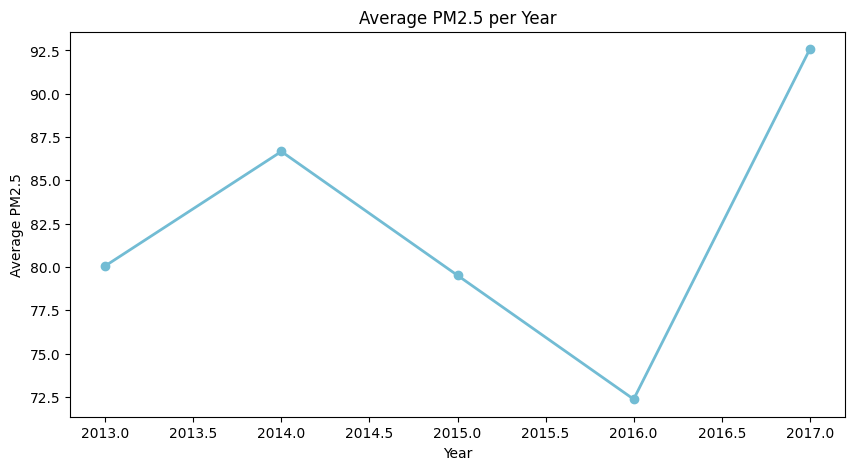

In [17]:
yearly_pm25_df = all_df.groupby("year").agg({
    "PM2.5": "mean"
}).reset_index()

yearly_pm25_df.rename(
    columns={"PM2.5": "avg_pm25"},
    inplace=True
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_pm25_df["year"],
    yearly_pm25_df["avg_pm25"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Average PM2.5 per Year")
plt.xlabel("Year")
plt.ylabel("Average PM2.5")

plt.show()

**Insight:**
- Konsentrasi PM2.5 mengalami fluktuasi sepanjang tahun.
- Nilai PM2.5 tertinggi terjadi pada tahun 2017 dengan nilai 92.5 μg/m³.
- Kualitas udara mengalami perubahan dari tahun ke tahun dan kembali meningkat pada akhir periode pengamatan.

### Pertanyaan 2: Pada bulan apa rata-rata PM2.5 tertinggi terjadi selama periode 2013-2017?

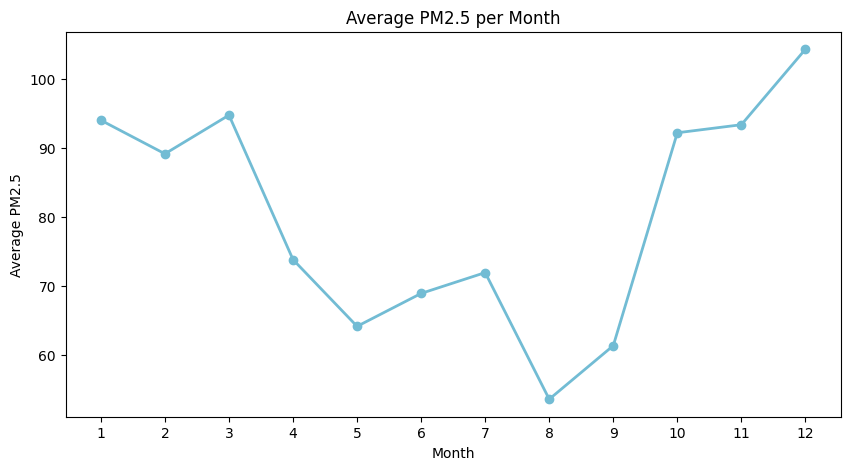

In [18]:
monthly_pm25_df = all_df.groupby("month").agg({
    "PM2.5": "mean"
}).reset_index()

monthly_pm25_df.rename(
    columns={"PM2.5": "avg_pm25"},
    inplace=True
)

plt.figure(figsize=(10,5))

plt.plot(
    monthly_pm25_df["month"],
    monthly_pm25_df["avg_pm25"],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Average PM2.5 per Month")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.xticks(monthly_pm25_df["month"])

plt.show()

**Insight:**

- Konsentrasi PM2.5 mengalami fluktuasi sepanjang bulan pengamatan.
- Nilai PM2.5 tertinggi terjadi pada bulan Desember dengan rata-rata sekitar 104 μg/m³, sedangkan nilai terendah terjadi pada bulan Agustus dengan rata-rata sekitar 54 μg/m³.

### Pertanyaan 3: Arah angin mana yang memiliki rata-rata PM2.5 tertinggi selama periode 2013-2017?

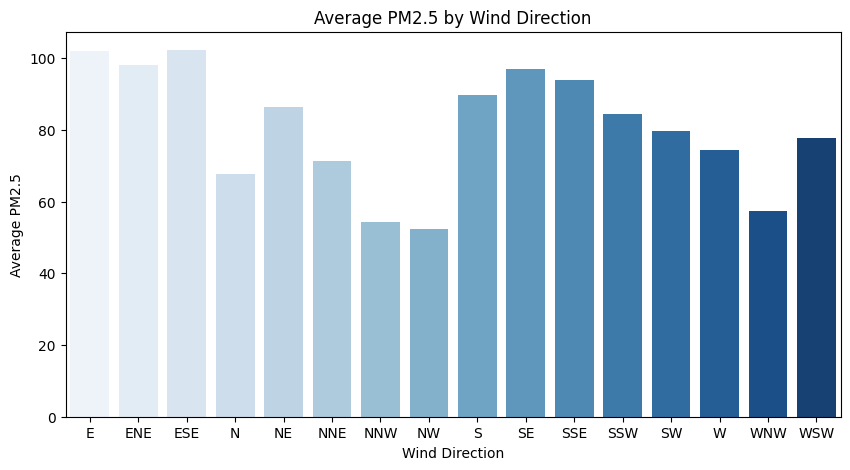

In [19]:
wd_pm25_df = all_df.groupby("wd").agg({
    "PM2.5": "mean"
}).reset_index()

wd_pm25_df.rename(columns={"PM2.5": "avg_pm25"}, inplace=True)

plt.figure(figsize=(10,5))

sns.barplot(
    data=wd_pm25_df,
    x="wd",
    y="avg_pm25",
    hue="wd",
    palette="Blues",
    legend=False
)

plt.title("Average PM2.5 by Wind Direction")
plt.xlabel("Wind Direction")
plt.ylabel("Average PM2.5")
plt.show()

**Insight:**
- Arah angin tertentu memiliki rata-rata PM2.5 yang lebih tinggi dibandingkan arah lainnya.
- Kondisi meteorologi memiliki pengaruh terhadap distribusi polusi udara.

## Analisis Lanjutan (Opsional)

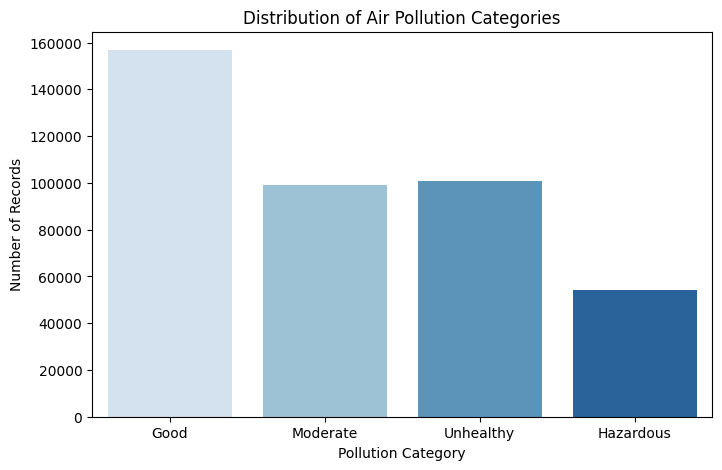

In [20]:
all_df["pollution_category"] = pd.cut(
    all_df["PM2.5"],
    bins=[0, 35, 75, 150, 300],
    labels=["Good", "Moderate", "Unhealthy", "Hazardous"]
)

pollution_df = all_df["pollution_category"].value_counts().reset_index()

pollution_df.columns = ["category", "count"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=pollution_df,
    x="category",
    y="count",
    hue="category",
    palette="Blues",
    legend=False
)

plt.title("Distribution of Air Pollution Categories")
plt.xlabel("Pollution Category")
plt.ylabel("Number of Records")
plt.show()

**Insight:**
- Analisis clustering sederhana menggunakan metode binning digunakan untuk mengelompokkan kualitas udara berdasarkan nilai PM2.5.
- Kategori Good memiliki jumlah data tertinggi.
- Kategori Moderate dan Unhealthy juga memiliki jumlah observasi yang cukup besar.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Rata-rata PM2.5 mengalami fluktuasi selama periode 2013–2017. Nilai rata-rata PM2.5 tertinggi terjadi pada tahun 2017 dengan nilai sekitar 92.5 μg/m³, sedangkan nilai terendah terjadi pada tahun 2016 dengan nilai sekitar 72.4 μg/m³. Hal ini menunjukkan bahwa kualitas udara mengalami perubahan dari tahun ke tahun dan kembali meningkat pada akhir periode pengamatan.
- **Conclusion pertanyaan 2:** Rata-rata PM2.5 tertinggi terjadi pada bulan Desember dengan nilai 104 μg/m³, sedangkan nilai terendah terjadi pada bulan Agustus dengan nilai 54 μg/m³. Hal ini menunjukkan bahwa kualitas udara cenderung memburuk pada akhir tahun dan membaik pada pertengahan tahun.
- **Conclusion pertanyaan 3:** Arah angin E dan ESE memiliki rata-rata PM2.5 lebih tinggi dibanding arah lain, yaitu 100 μg/m³. Hal ini menunjukkan pengaruh kondisi meteorologi terhadap kualitas udara.

**Rekomendasi Action Item:**
- Pemerintah perlu meningkatkan pengawasan emisi kendaraan dan industri terutama pada periode dengan konsentrasi polusi tinggi.
- Pemantauan kualitas udara perlu ditingkatkan pada kondisi arah angin tertentu.
- Masyarakat disarankan mengurangi aktivitas luar ruangan saat kualitas udara berada pada kategori tidak sehat.

In [21]:
all_df.to_csv("main_data.csv", index=False)